Season summary ready: (24, 6)


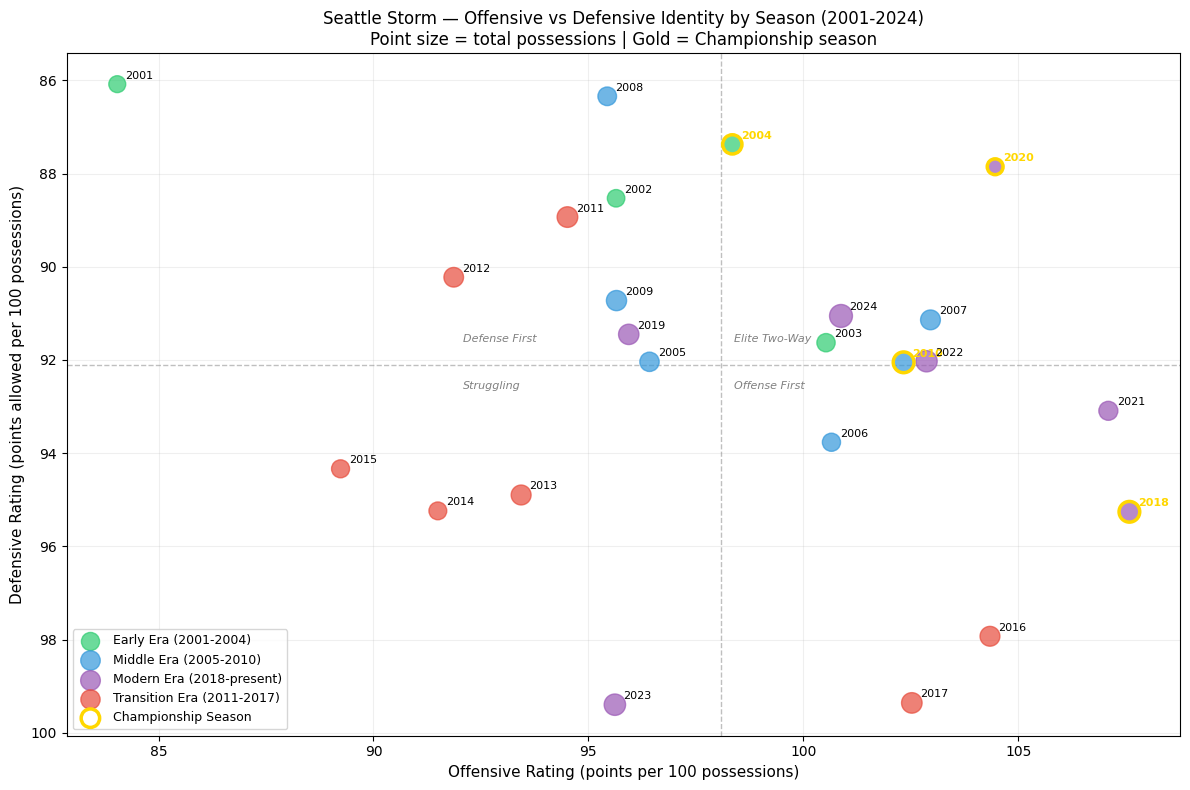

Saved to outputs/storm_identity_scatter.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# Championship years to highlight
championships = [2004, 2010, 2018, 2020]

# Load data
adv_df = pd.read_csv('../data/raw/storm_lineups_advanced.csv')

# Filter and aggregate
POSS_THRESHOLD = 20

df = adv_df[['SEASON', 'GROUP_NAME', 'MIN', 'GP', 'OFF_RATING', 'DEF_RATING', 'NET_RATING', 'PACE', 'POSS']].copy()
df_filtered = df[df['POSS'] >= POSS_THRESHOLD].copy()

# Possession-weighted season summary
season_summary = df_filtered.groupby('SEASON').apply(
    lambda x: pd.Series({
        'OFF_RATING': (x['OFF_RATING'] * x['POSS']).sum() / x['POSS'].sum(),
        'DEF_RATING': (x['DEF_RATING'] * x['POSS']).sum() / x['POSS'].sum(),
        'NET_RATING': (x['NET_RATING'] * x['POSS']).sum() / x['POSS'].sum(),
        'TOTAL_POSS': x['POSS'].sum(),
        'LINEUP_COUNT': len(x)
    })
).reset_index()

# Drop 2000 — data quality issue
season_summary = season_summary[season_summary['SEASON'] > 2000].copy()

os.makedirs('../outputs', exist_ok=True)

print(f"Season summary ready: {season_summary.shape}")

# Create era labels
def get_era(season):
    if season <= 2004:
        return 'Early Era (2001-2004)'
    elif season <= 2010:
        return 'Middle Era (2005-2010)'
    elif season <= 2017:
        return 'Transition Era (2011-2017)'
    else:
        return 'Modern Era (2018-present)'

season_summary['ERA'] = season_summary['SEASON'].apply(get_era)

era_colors = {
    'Early Era (2001-2004)': '#2ecc71',
    'Middle Era (2005-2010)': '#3498db',
    'Transition Era (2011-2017)': '#e74c3c',
    'Modern Era (2018-present)': '#9b59b6'
}

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each era
for era, group in season_summary.groupby('ERA'):
    ax.scatter(
        group['OFF_RATING'],
        group['DEF_RATING'],
        c=era_colors[era],
        s=group['TOTAL_POSS'] / 10,  # size by possessions
        alpha=0.7,
        label=era,
        zorder=3
    )

# Label each point with season
for _, row in season_summary.iterrows():
    is_champ = row['SEASON'] in championships
    ax.annotate(
        str(int(row['SEASON'])),
        (row['OFF_RATING'], row['DEF_RATING']),
        textcoords='offset points',
        xytext=(6, 4),
        fontsize=8,
        fontweight='bold' if is_champ else 'normal',
        color='gold' if is_champ else 'black'
    )

# Add championship markers
champ_data = season_summary[season_summary['SEASON'].isin(championships)]
ax.scatter(
    champ_data['OFF_RATING'],
    champ_data['DEF_RATING'],
    s=champ_data['TOTAL_POSS'] / 10,
    facecolors='none',
    edgecolors='gold',
    linewidths=2.5,
    zorder=4,
    label='Championship Season'
)

# Quadrant lines — league average approximations
avg_off = season_summary['OFF_RATING'].mean()
avg_def = season_summary['DEF_RATING'].mean()

ax.axvline(avg_off, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(avg_def, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Quadrant labels
ax.text(avg_off + 0.3, avg_def - 0.5, 'Elite Two-Way', fontsize=8, color='gray', style='italic')
ax.text(avg_off - 6, avg_def - 0.5, 'Defense First', fontsize=8, color='gray', style='italic')
ax.text(avg_off + 0.3, avg_def + 0.5, 'Offense First', fontsize=8, color='gray', style='italic')
ax.text(avg_off - 6, avg_def + 0.5, 'Struggling', fontsize=8, color='gray', style='italic')

# Remember — lower DEF_RATING is better, so invert y axis
ax.invert_yaxis()

ax.set_xlabel('Offensive Rating (points per 100 possessions)', fontsize=11)
ax.set_ylabel('Defensive Rating (points allowed per 100 possessions)', fontsize=11)
ax.set_title('Seattle Storm — Offensive vs Defensive Identity by Season (2001-2024)\nPoint size = total possessions | Gold = Championship season', fontsize=12)
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../outputs/storm_identity_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved to outputs/storm_identity_scatter.png")